<a href="https://colab.research.google.com/github/Saadmoquim/physicscode/blob/main/PHY421_midsem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Neumann parameter = 0.08888888888888889


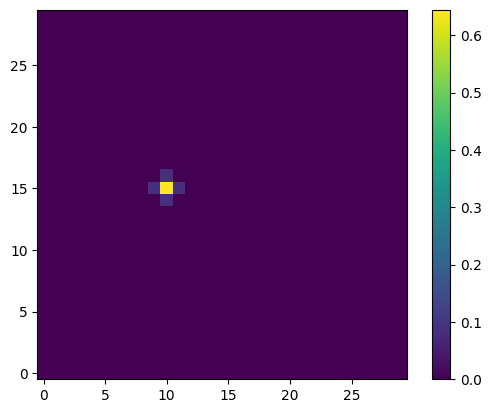

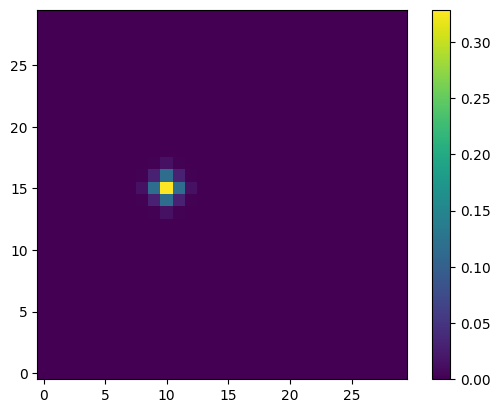

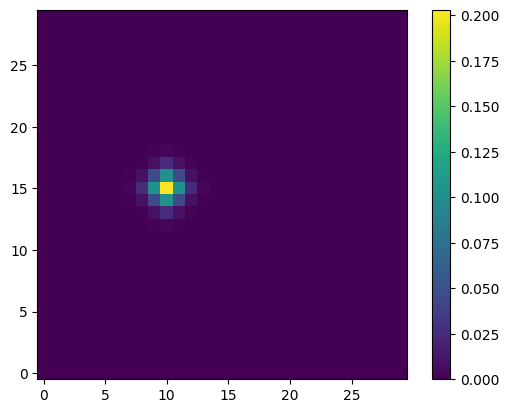

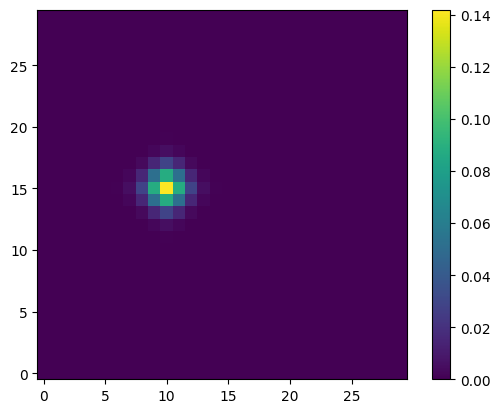

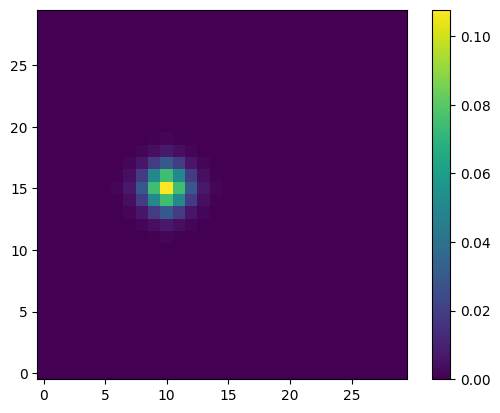

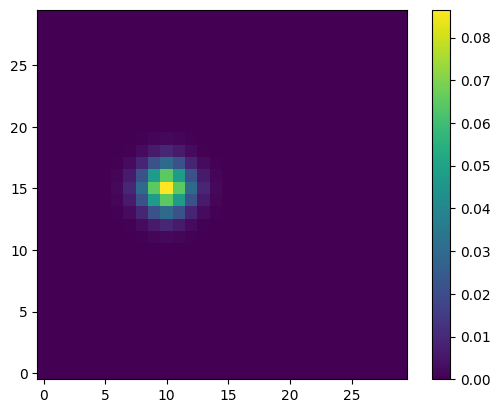

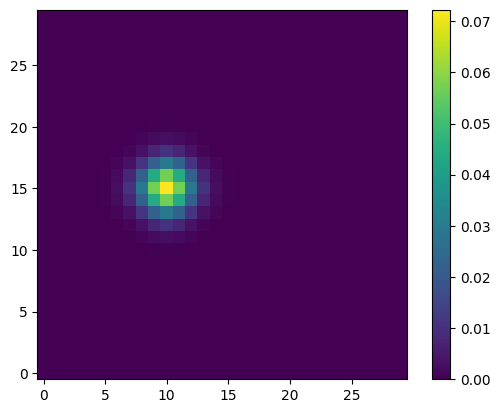

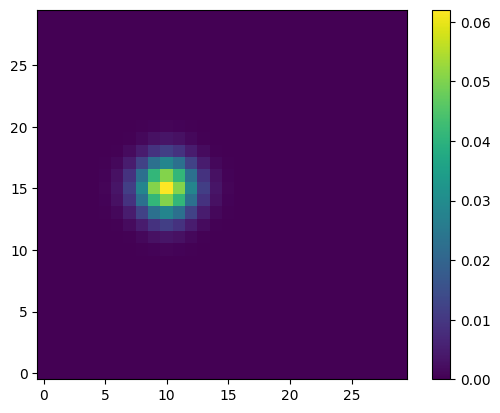

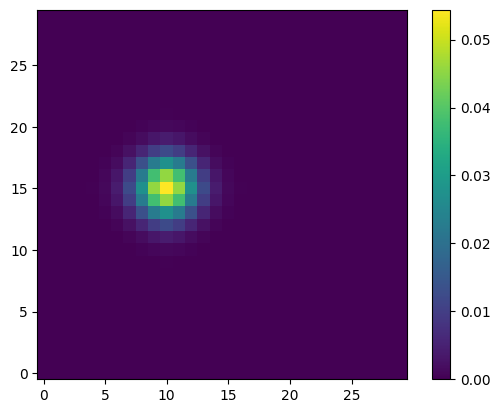

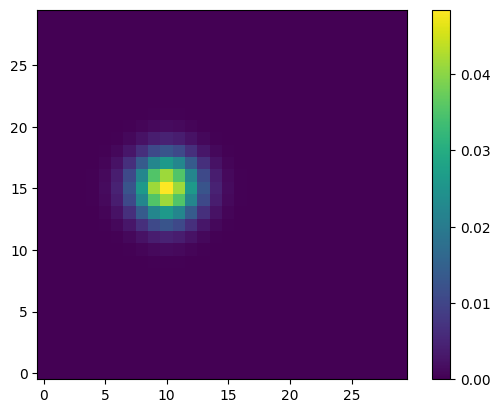

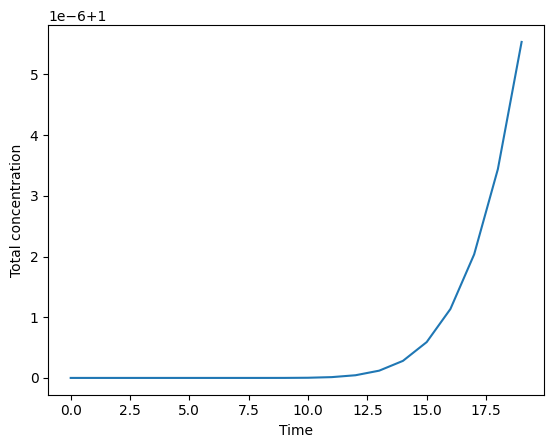

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
L = 30          # System size
N = 20        # Number of time steps
delt = 0.1      # Time step
delx = 0.15     # Spatial step
D = 0.02        # Diffusion constant

# Stability parameter (Neumann number)
Neumann_para = D * delt / delx**2
print("Neumann parameter =", Neumann_para)

# Initialize concentration field
c = np.zeros((L, L))
c0 = np.zeros((L, L))

# Initial condition
c0[L//2, 10] = 1
c = c0.copy()

# Storage
cT = np.zeros((N, L, L))
n = np.zeros(N)

# Time evolution
for i in range(N):

    # Periodic boundary conditions
    c[0, :] = c[-2, :]
    c[-1, :] = c[1, :]
    c[:, 0] = c[:, -2]
    c[:, -1] = c[:, 1]

    # Compute Laplacian (vectorized)
    laplacian = (
        np.roll(c, 1, axis=0) +
        np.roll(c, -1, axis=0) +
        np.roll(c, 1, axis=1) +
        np.roll(c, -1, axis=1) -
        4 * c
    )

    c = c + Neumann_para * laplacian

    cT[i] = c
    n[i] = np.sum(c)

# Animation
plt.figure()
for i in range(0, N, 2):
    plt.clf()
    plt.imshow(cT[i], origin='lower')
    plt.colorbar()
    plt.pause(0.001)

# Plot total concentration
plt.figure()
plt.plot(n)
plt.ylabel("Total concentration")
plt.xlabel("Time")
plt.show()


Neumann parameter = 0.08888888888888889


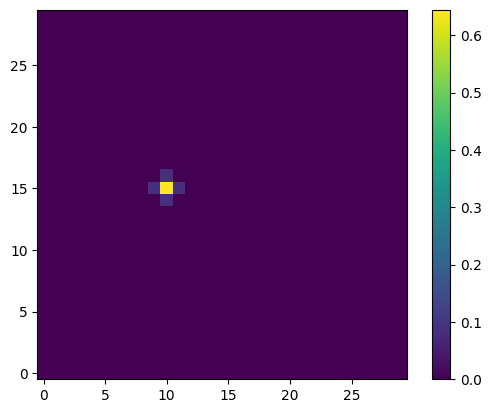

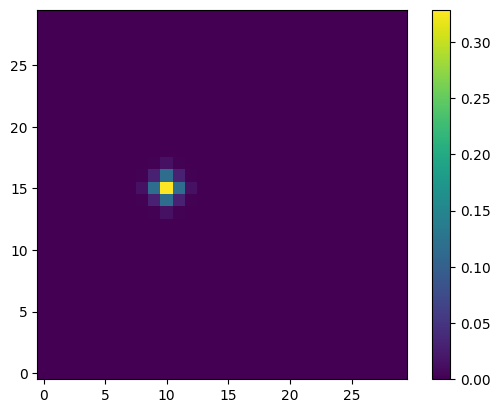

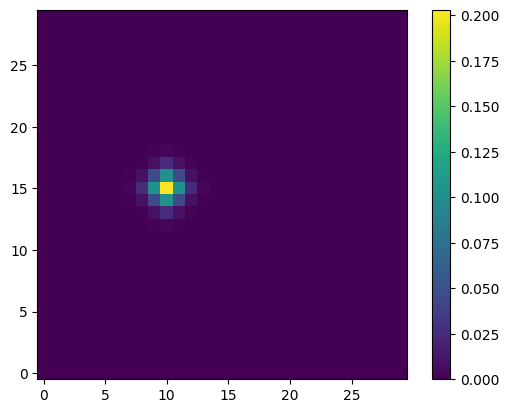

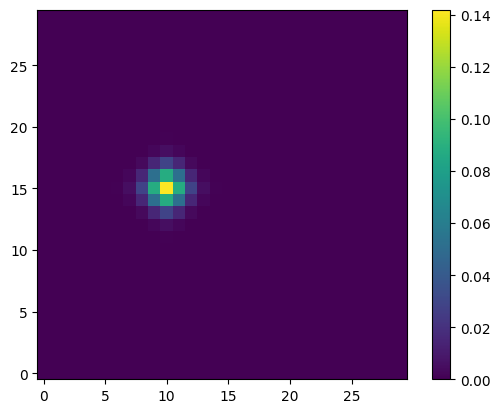

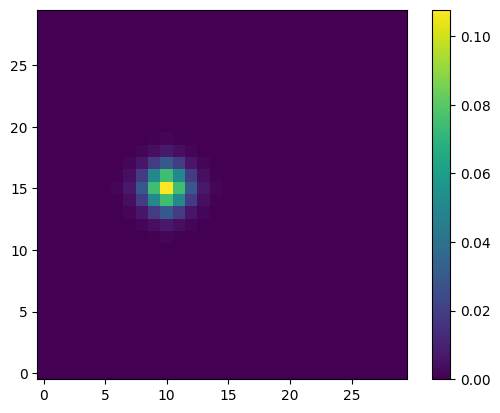

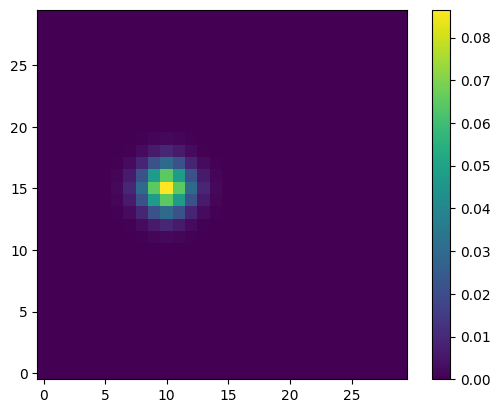

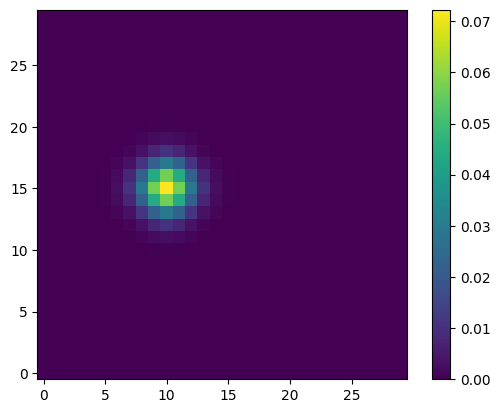

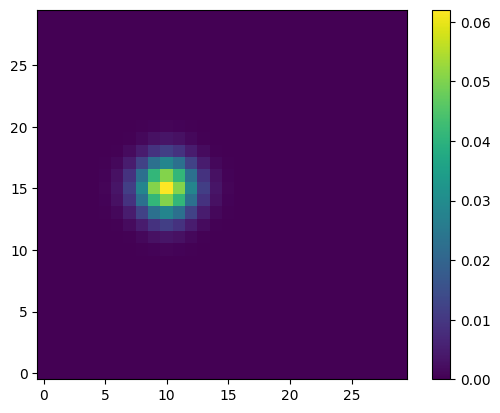

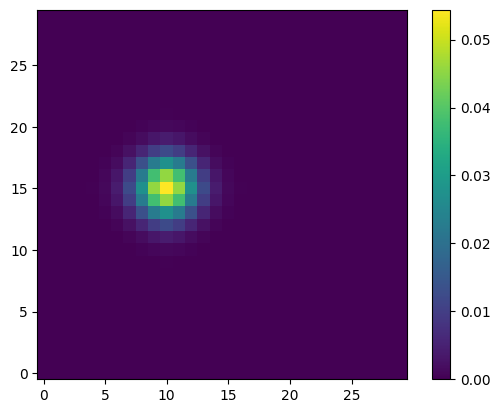

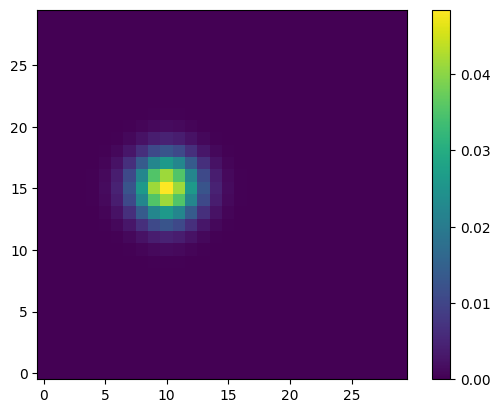

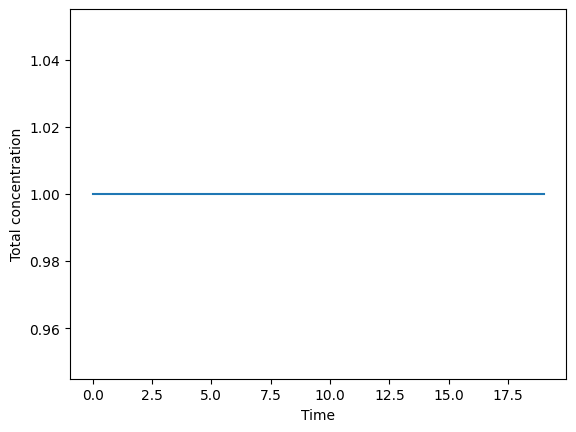

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
L = 30          # System size
N = 20      # Number of iterations
delt = 0.1      # Time step
delx = 0.15     # Spatial step
D = 0.02        # Diffusion constant

# Stability parameter
Neumann_para = D * delt / (delx**2)
print("Neumann parameter =", Neumann_para)

# Initialize fields
c = np.zeros((L, L))
c0 = np.zeros((L, L))
ctemp = np.zeros((L, L))

# Initial condition
c0[L//2, 10] = 1
c = c0.copy()

# Storage
cT = np.zeros((N, L, L))
n = np.zeros(N)

# Time evolution
for i in range(N):

    # --- Neumann (no-flux) boundary condition ---
    c[0, :]  = c[1, :]
    c[-1, :] = c[-2, :]
    c[:, 0]  = c[:, 1]
    c[:, -1] = c[:, -2]

    # Update interior points
    for p in range(1, L-1):
        for q in range(1, L-1):
            nL = c[p, q-1]
            nR = c[p, q+1]
            nT = c[p-1, q]
            nB = c[p+1, q]

            ctemp[p, q] = c[p, q] + Neumann_para * (
                nL + nR + nT + nB - 4*c[p, q]
            )

    c = ctemp.copy()
    cT[i] = c
    n[i] = np.sum(c)

# Animation
plt.figure()
for i in range(0, N, 2):
    plt.clf()
    plt.imshow(cT[i], origin='lower')
    plt.colorbar()
    plt.pause(0.001)

# Plot total concentration (should remain constant)
plt.figure()
plt.plot(n)
plt.ylabel("Total concentration")
plt.xlabel("Time")
plt.show()


enter diffusion constant0.2
neumann parameter= 0.19999999999999996


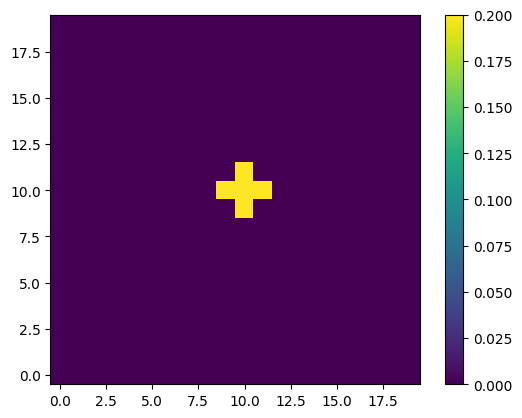

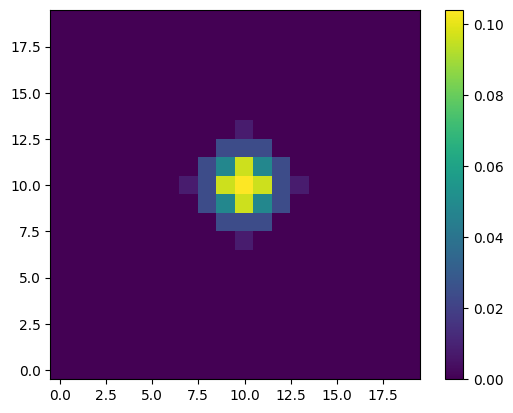

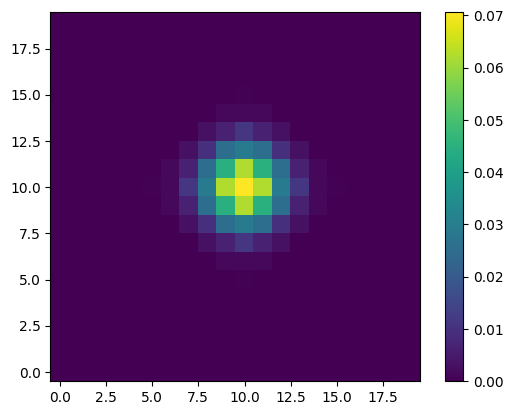

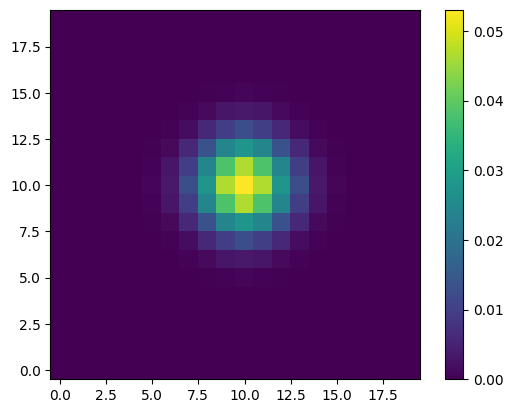

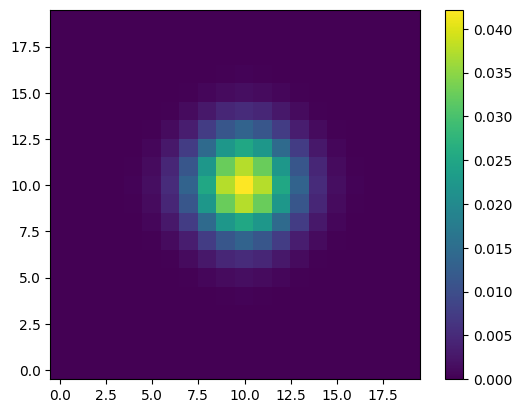

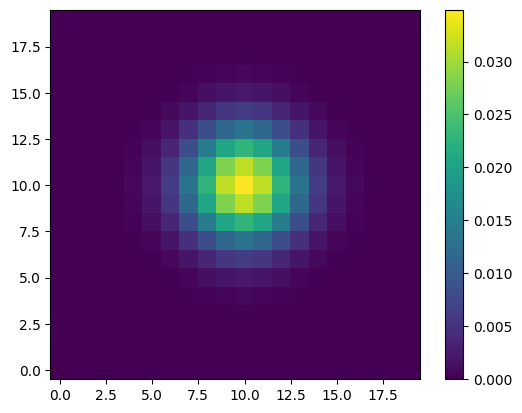

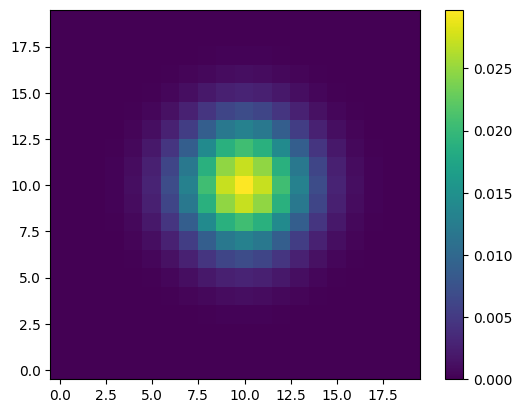

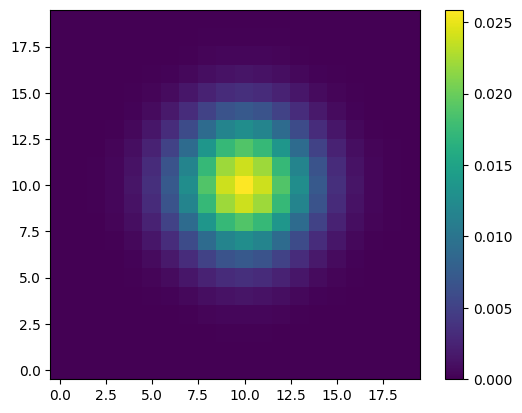

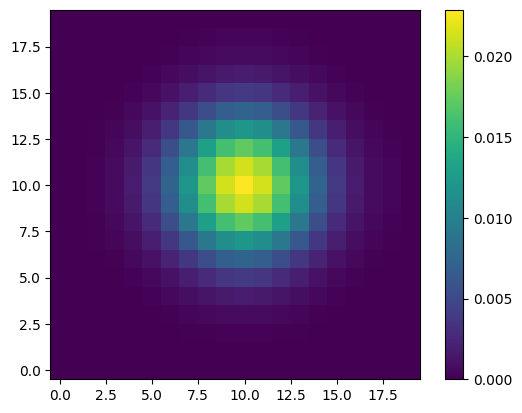

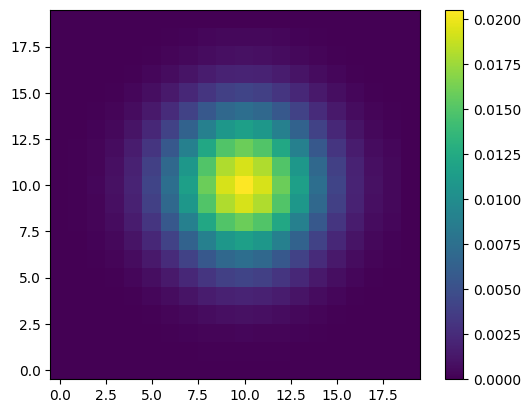

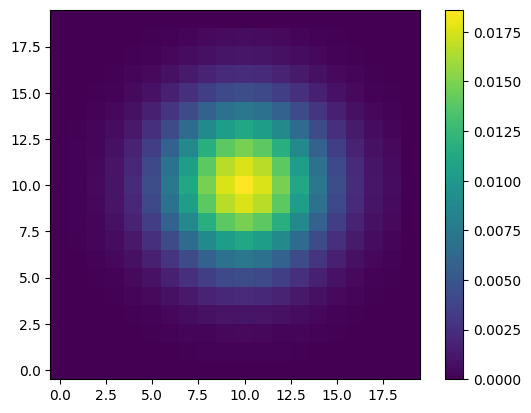

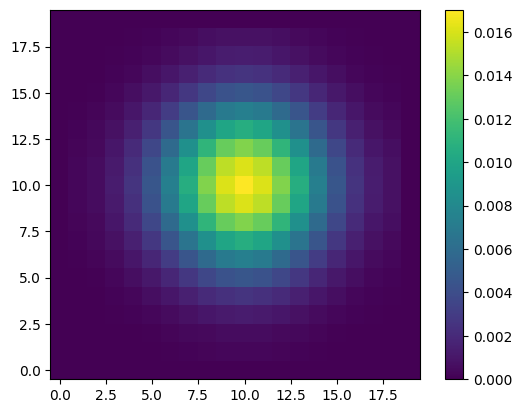

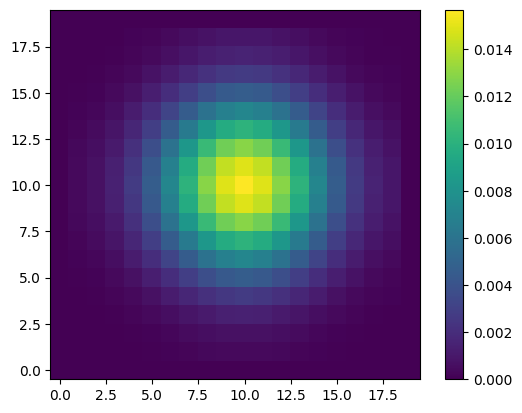

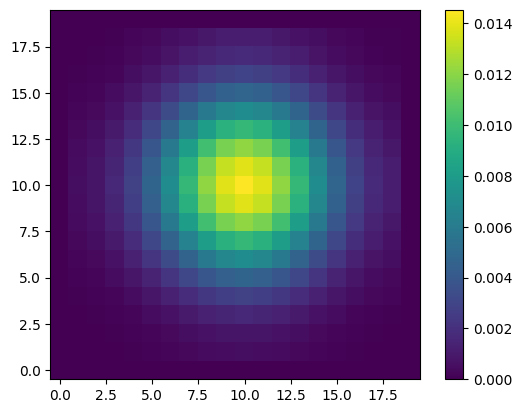

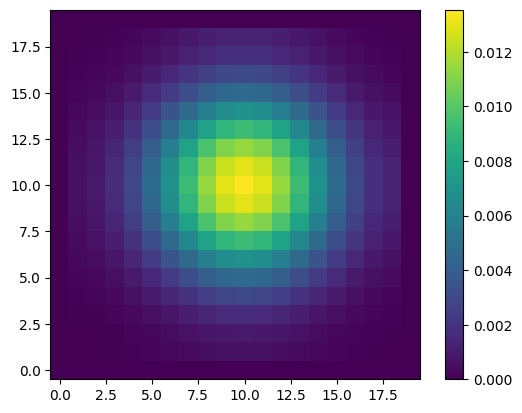

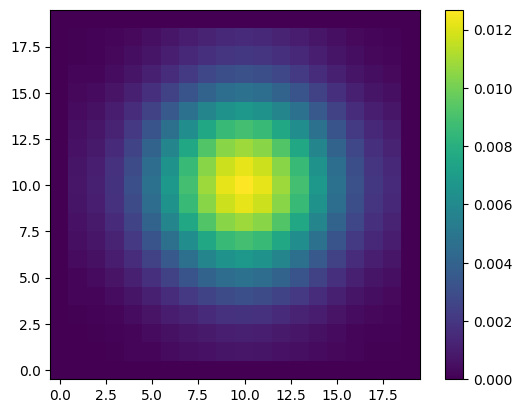

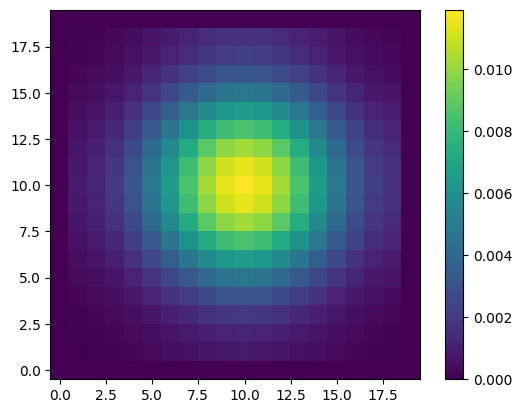

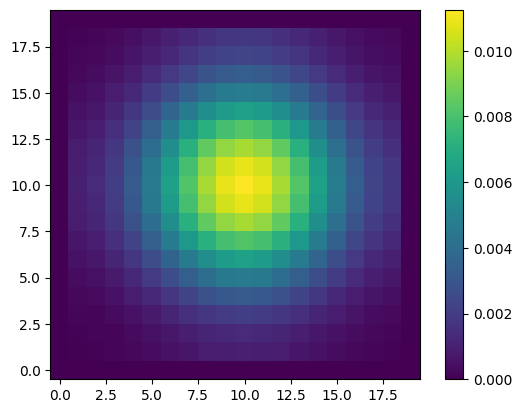

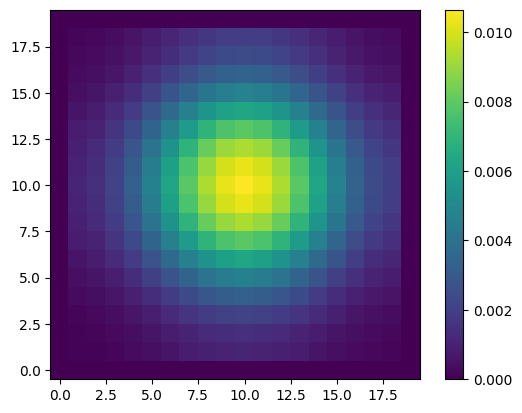

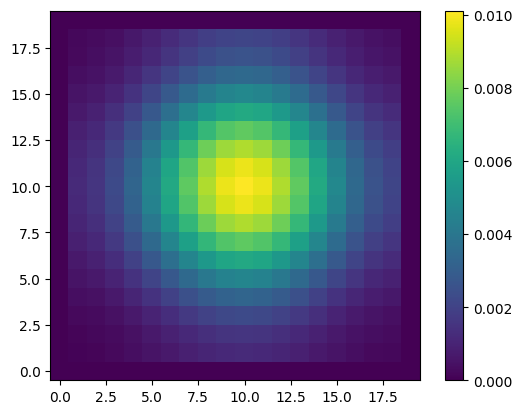

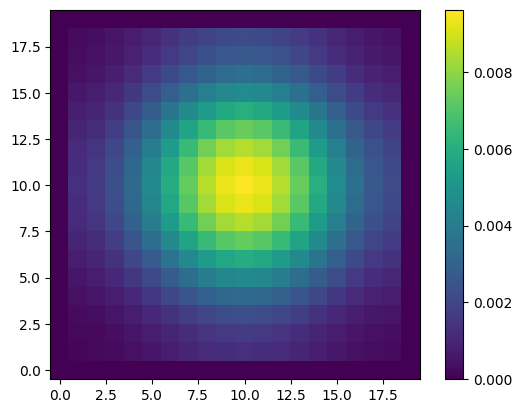

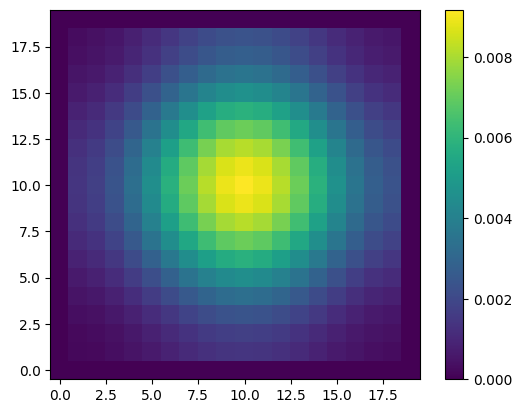

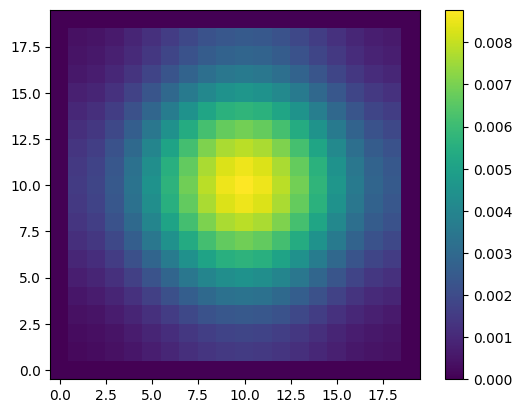

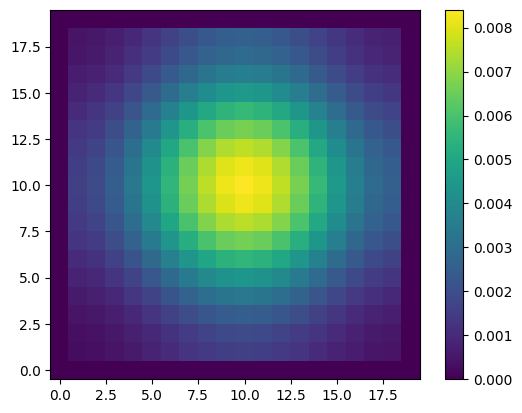

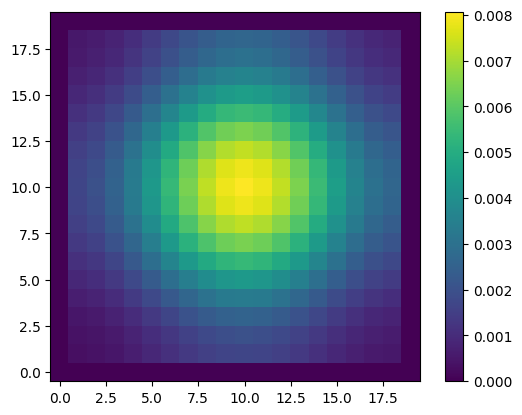

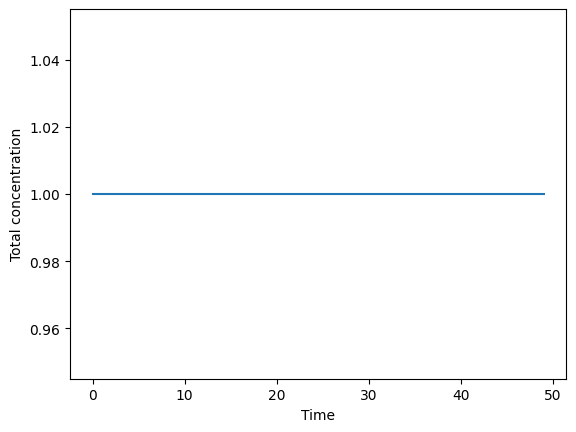

In [18]:
import numpy as np
import matplotlib.pyplot as plt

L=20
N=50
delt=0.01
delx=0.1
D=float(input("enter diffusion constant"))

r=D*delt/(delx**2)
print("neumann parameter=",r)

#setting the fields
c=np.zeros((L,L))
c0=np.zeros((L,L))
ctemp=np.zeros((L,L))

#initial conditions
c0[10,10]=1
c=c0.copy()

#storing
cT=np.zeros((N,L,L))
n=np.zeros(N)

for i in range(N):
    c[0, :]  = c[1, :]
    c[-1, :] = c[-2, :]
    c[:, 0]  = c[:, 1]
    c[:, -1] = c[:, -2]

    for p in range (1,L-1):
      for q in range(1,L-1):
        nL=c[p,q-1]
        nR=c[p,q+1]
        nT=c[p+1,q]
        nB=c[p-1,q]

        ctemp[p,q]=c[p,q]+r*(nL+nR+nT+nB-4*c[p,q])

    c=ctemp.copy()
    cT[i]=c
    n[i]=np.sum(c)

plt.figure()
for i in range(0, N, 2):
    plt.clf()
    plt.imshow(cT[i], origin='lower')
    plt.colorbar()
    plt.pause(0.001)

# Plot total concentration (should remain constant)
plt.figure()
plt.plot(n)
plt.ylabel("Total concentration")
plt.xlabel("Time")
plt.show()

Laplace solution done numerically(Gauss Seidel)

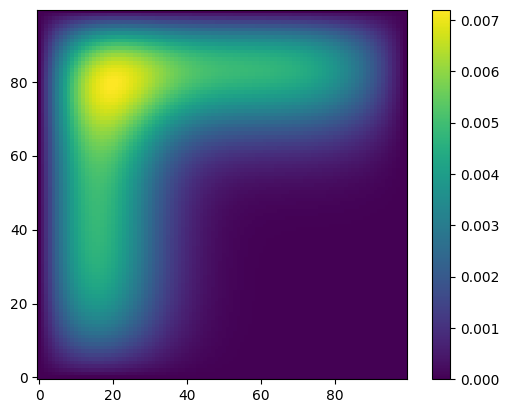

In [29]:
import numpy as np
import matplotlib.pyplot as plt

L = 100
N = 500

V = np.zeros((L, L))
Vtemp = np.zeros((L, L))

# Boundary conditions
V[:, 0]  = 10   # left
V[:, -1] = 0   # right
V[0, :]  = 0   # bottom
V[-1, :] = 10   # top

for n in range(N):

    for i in range(1, L-1):
        for j in range(1, L-1):
            Vtemp[i,j] = 0.25 * (
                V[i+1,j] + V[i-1,j] +
                V[i,j+1] + V[i,j-1]
            )

    V = Vtemp.copy()

plt.figure()
plt.imshow(V, origin='lower')
plt.colorbar()
plt.show()


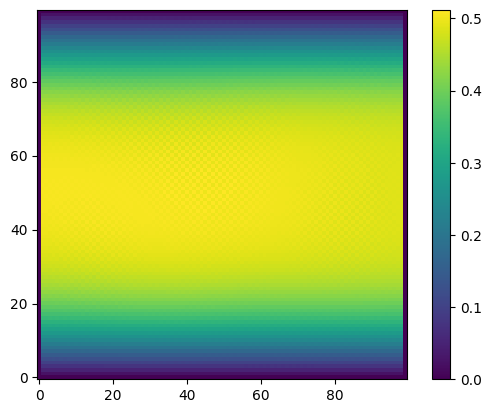

In [34]:
import numpy as np
import matplotlib.pyplot as plt

L = 100
N = 500

V = np.random.rand(L, L)
Vtemp = np.zeros((L, L))
V[0, :]  = 1
V[-1, :] = 0
for n in range(N):

    # Enforce Neumann boundary

    V[:, 0]  = V[:, 1]
    V[:, -1] = V[:, -2]

    # Interior update
    for i in range(1, L-1):
        for j in range(1, L-1):
            Vtemp[i,j] = 0.25 * (
                V[i+1,j] + V[i-1,j] +
                V[i,j+1] + V[i,j-1]
            )

    V = Vtemp.copy()

plt.figure()
plt.imshow(V, origin='lower')
plt.colorbar()
plt.show()


Non linear dynamics


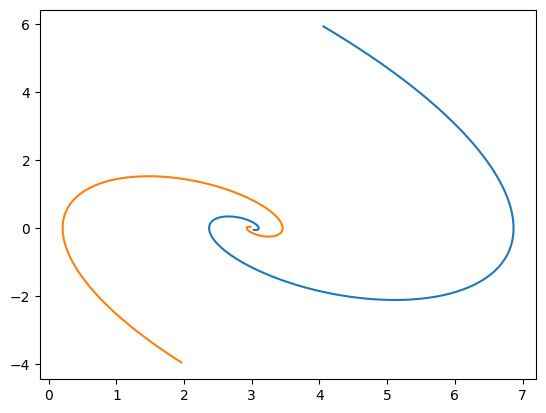

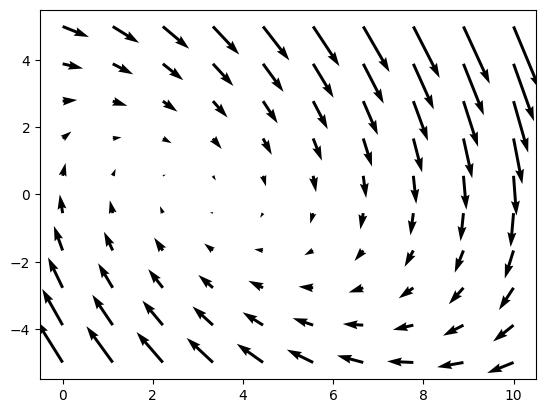

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def f(x,y):
  dx=y
  dy=3-x-y
  return dx,dy

x=np.linspace(0,10,10)
y=np.linspace(-5,5,10)
X,Y=np.meshgrid(x,y)
DX,DY=f(X,Y)

def rk4(x0,y0,dt,N):
  xs,ys=[],[]
  x,y=x0,y0

  for _ in range(N):
    k1x,k1y = f(x,y)
    k2x,k2y = f(x+dt*k1x/2, y+dt*k1y/2)
    k3x,k3y = f(x+dt*k2x/2, y+dt*k2y/2)
    k4x,k4y = f(x+dt*k3x, y+dt*k3y)

    x += dt*(k1x+2*k2x+2*k3x+k4x)/6
    y += dt*(k1y+2*k2y+2*k3y+k4y)/6

    xs.append(x)
    ys.append(y)
  return xs,ys

IC=[(4,6),(2,-4)]

for ic in IC:
  xs,ys=rk4(ic[0],ic[1],0.01,1000)
  plt.plot(xs,ys)

plt.figure()
plt.quiver(X,Y,DX,DY)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

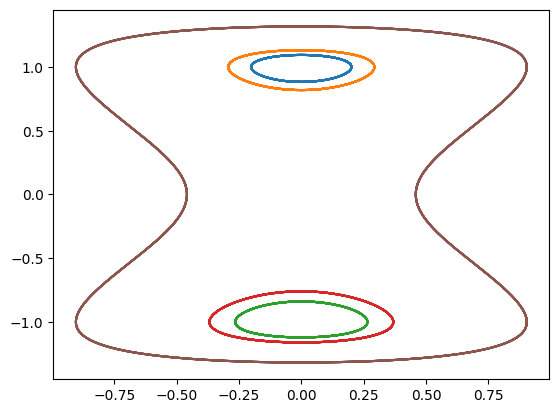

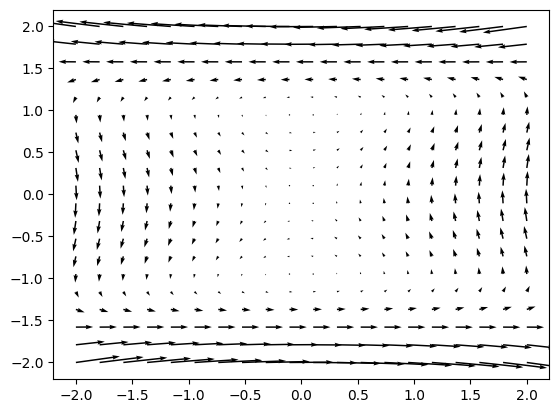

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def f(x,y):
  dx=y-y**3
  dy=x*np.cos(y)
  return dx,dy

x=np.linspace(-2,2,20)
y=np.linspace(-2,2,20)
X,Y=np.meshgrid(x,y)
DX,DY=f(X,Y)

def f(x,y):
    return y - y**3, x*np.cos(y)

def rk4(x0,y0,dt,steps):
    xs, ys = [], []
    x,y = x0,y0
    for _ in range(steps):
        k1x,k1y = f(x,y)
        k2x,k2y = f(x+dt*k1x/2, y+dt*k1y/2)
        k3x,k3y = f(x+dt*k2x/2, y+dt*k2y/2)
        k4x,k4y = f(x+dt*k3x, y+dt*k3y)

        x += dt*(k1x+2*k2x+2*k3x+k4x)/6
        y += dt*(k1y+2*k2y+2*k3y+k4y)/6

        xs.append(x)
        ys.append(y)
    return xs, ys

ICs = [
    (0.1, 0.9),
    (-0.2, 1.1),
    (0.2, -0.9),
    (-0.3, -1.1),
    (0.5,0.2),   # near saddle
    (-0.5,-0.2)
]

for ic in ICs:
    xs, ys = rk4(ic[0], ic[1], 0.01, 4000)
    plt.plot(xs, ys)



plt.figure()
plt.quiver(X,Y,DX,DY)
plt.show

/tmp/ipython-input-1044955108.py:9: RuntimeWarning: overflow encountered in scalar power
  dy = y**2 - x
/tmp/ipython-input-1044955108.py:8: RuntimeWarning: invalid value encountered in sin
  dx = np.sin(y)


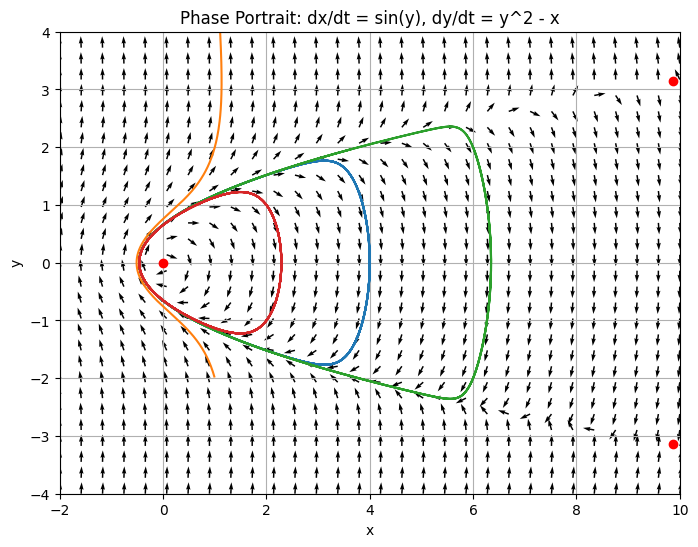

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Vector field
# ----------------------------
def f(x, y):
    dx = np.sin(y)
    dy = y**2 - x
    return dx, dy

# ----------------------------
# Grid for quiver
# ----------------------------
x = np.linspace(-2, 10, 30)
y = np.linspace(-4, 4, 30)
X, Y = np.meshgrid(x, y)

DX, DY = f(X, Y)

# Normalize arrows for better visualization
M = np.sqrt(DX**2 + DY**2)
M[M == 0] = 1
DXn = DX / M
DYn = DY / M

# ----------------------------
# RK4 Integrator
# ----------------------------
def rk4(x0, y0, dt, N):
    xs = []
    ys = []
    x, y = x0, y0

    for _ in range(N):
        k1x, k1y = f(x, y)
        k2x, k2y = f(x + dt*k1x/2, y + dt*k1y/2)
        k3x, k3y = f(x + dt*k2x/2, y + dt*k2y/2)
        k4x, k4y = f(x + dt*k3x, y + dt*k3y)

        x += dt*(k1x + 2*k2x + 2*k3x + k4x)/6
        y += dt*(k1y + 2*k2y + 2*k3y + k4y)/6

        xs.append(x)
        ys.append(y)

    return np.array(xs), np.array(ys)

# ----------------------------
# Plot everything together
# ----------------------------
plt.figure(figsize=(8,6))

# Vector field
plt.quiver(X, Y, DXn, DYn)

# Fixed points: x = (nπ)^2 , y = nπ
for n in range(-3, 4):
    y_star = n * np.pi
    x_star = y_star**2
    plt.plot(x_star, y_star, 'ro')

# Trajectories
IC = [(4,0), (1,-2), (6,2), (2,1)]

for ic in IC:
    xs, ys = rk4(ic[0], ic[1], 0.01, 5000)
    plt.plot(xs, ys)

plt.xlim(-2, 10)
plt.ylim(-4, 4)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Phase Portrait: dx/dt = sin(y), dy/dt = y^2 - x")
plt.grid()
plt.show()



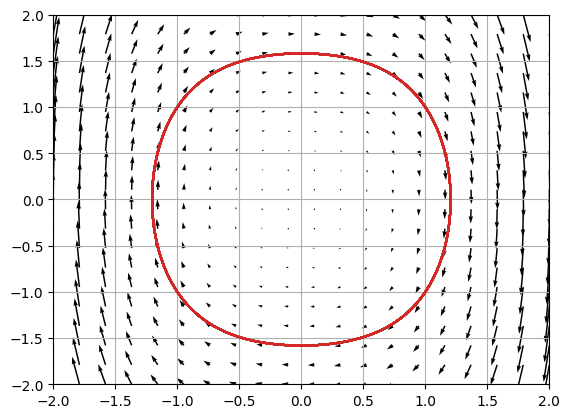

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def f(x,y):
    dx = y
    dy = -x - x**3
    return dx, dy

def rk4(x0,y0,dt,N):
    xs, ys = [], []
    x, y = x0, y0
    for _ in range(N):
        kx1,ky1 = f(x,y)
        kx2,ky2 = f(x+dt*kx1/2,y+dt*ky1/2)
        kx3,ky3 = f(x+dt*kx2/2,y+dt*ky2/2)
        kx4,ky4 = f(x+dt*kx3,y+dt*ky3)

        x += dt*(kx1+2*kx2+2*kx3+kx4)/6
        y += dt*(ky1+2*ky2+2*ky3+ky4)/6

        xs.append(x)
        ys.append(y)

    return xs, ys


# Create figure FIRST
plt.figure()

# Vector field
x = np.linspace(-2,2,20)
y = np.linspace(-2,2,20)
X,Y = np.meshgrid(x,y)
DX,DY = f(X,Y)

plt.quiver(X,Y,DX,DY)

# Trajectories
IC = [(1,1), (-1,1), (1,-1), (-1,-1)]

for ic in IC:
    xs, ys = rk4(ic[0], ic[1], 0.01, 5000)
    plt.plot(xs, ys)

plt.xlim(-2,2)
plt.ylim(-2,2)
plt.grid()
plt.show()


enter value of q1


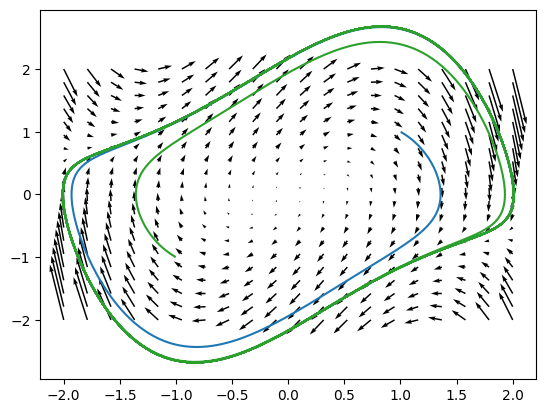

In [30]:
q=float(input("enter value of q"))
def f(x,y):
    dx = y
    dy = q*(1-x**2)*y-x
    return dx, dy

def rk4(x0,y0,dt,N):
  xs,ys=[],[]
  x,y=x0,y0
  for _ in range(N):
    k1x,k1y=f(x,y)
    k2x,k2y=f(x+dt*k1x/2,y+dt*k1y/2)
    k3x,k3y=f(x+dt*k2x/2,y+dt*k2y/2)
    k4x,k4y=f(x+dt*k3x,y+dt*k3y)

    x+=dt*(k1x+2*k2x+2*k3x+k4x)/6
    y+=dt*(k1y+2*k2y+2*k3y+k4y)/6
    xs.append(x)
    ys.append(y)
  return xs,ys

plt.figure()

IC=[(1,1),(0,0),(-1,-1)]
for ic in IC:
  xs,ys=rk4(ic[0],ic[1],0.01,5000)
  plt.plot(xs,ys)

x=np.linspace(-2,2,20)
y=np.linspace(-2,2,20)
X,Y=np.meshgrid(x,y)
DX,DY=f(X,Y)

plt.quiver(X,Y,DX,DY)
plt.show()

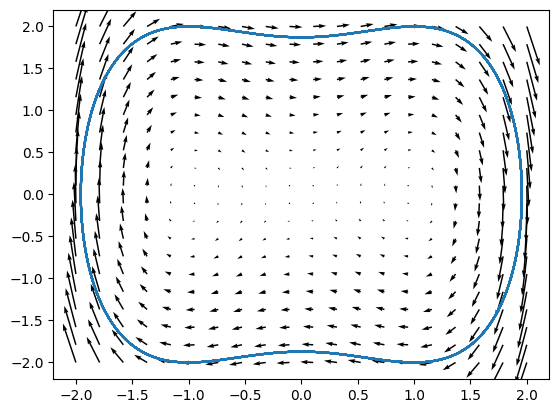

In [33]:
def f(x,y):
  dx=y
  dy=x-x**3
  return dx,dy

def rk4(x0,y0,dt,N):
  xs,ys=[],[]
  x,y=x0,y0
  for _ in range(N):
    kx1,ky1=f(x,y)
    kx2,ky2=f(x+dt*kx1/2,y+dt*ky1/2)
    kx3,ky3=f(x+dt*kx2/2,y+dt*ky2/2)
    kx4,ky4=f(x+dt*kx3,y+dt*ky3)
    x+=dt*(kx1+2*kx2+2*kx3+kx4)/6
    y+=dt*(ky1+2*ky2+2*ky3+ky4)/6
    xs.append(x)
    ys.append(y)
  return xs,ys

plt.figure()

IC=[(1,2),(0,0)]
for ic in IC:
  xs,ys=rk4(ic[0],ic[1],0.01,5000)
  plt.plot(xs,ys)

x=np.linspace(-2,2,20)
y=np.linspace(-2,2,20)
X,Y=np.meshgrid(x,y)
DX,DY=f(X,Y)

plt.quiver(X,Y,DX,DY)
plt.show()

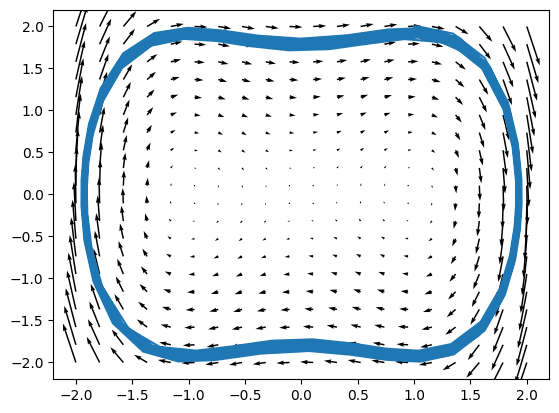

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp as ivpsol

def f(t,z):
  x,y=z
  dx=y
  dy=x-x**3
  return dx,dy

plt.figure()

IC=[(1,2),(0,0)]

for ic in IC:
  sol=ivpsol(f,t_span=(0,50),y0=ic,method='RK23')
  plt.plot(sol.y[0],sol.y[1])

x=np.linspace(-2,2,20)
y=np.linspace(-2,2,20)
X,Y=np.meshgrid(x,y)
DX,DY=f(0,[X,Y])

plt.quiver(X,Y,DX,DY)
plt.show()

In [41]:
r=float(input("enter bifurcation parameter value parameter:"))
def f(x,y):
  dx=y
  dy=r+x**2
  return dx,dy

def rk4(x0,y0,dt,N):
  xs,ys=[],[]
  x,y=x0,y0
  for _ in range(N):
    kx1,ky1=f(x,y)
    kx2,ky2=f(x+dt*kx1/2,y+dt*ky1/2)
    kx3,ky3=f(x+dt*kx2/2,y+dt*ky2/2)
    kx4,ky4=f(x+dt*kx3,y+dt*ky3)
    x+=dt*(kx1+2*kx2+2*kx3+kx4)/6
    y+=dt*(ky1+2*ky2+2*ky3+ky4)/6
    xs.append(x)
    ys.append(y)
  return xs,ys

plt.figure()

IC=[(0,0), (1,0), (-1,0), (0.5,0.5)]
for ic in IC:
  xs,ys=rk4(ic[0],ic[1],0.001,5000)
  plt.plot(xs,ys)

x=np.linspace(-2,2,20)
y=np.linspace(-2,2,20)
X,Y=np.meshgrid(x,y)
DX,DY=f(X,Y)

plt.quiver(X,Y,DX,DY)
plt.show()

enter bifurcation parameter value parameter:1


OverflowError: (34, 'Numerical result out of range')

<Figure size 640x480 with 0 Axes>

Enter value of mu: 1


OverflowError: (34, 'Numerical result out of range')

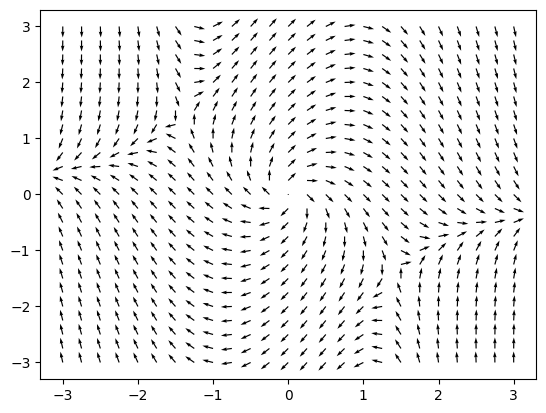

In [45]:
import numpy as np
import matplotlib.pyplot as plt

mu = float(input("Enter value of mu: "))

def f(x,y):
    dx = y + mu*x
    dy = -x + mu*y - x**2*y
    return dx, dy

def rk4(x0,y0,dt,N):
    xs, ys = [], []
    x, y = x0, y0

    for _ in range(N):
        k1x, k1y = f(x,y)
        k2x, k2y = f(x+dt*k1x/2, y+dt*k1y/2)
        k3x, k3y = f(x+dt*k2x/2, y+dt*k2y/2)
        k4x, k4y = f(x+dt*k3x, y+dt*k3y)

        x += dt*(k1x+2*k2x+2*k3x+k4x)/6
        y += dt*(k1y+2*k2y+2*k3y+k4y)/6

        xs.append(x)
        ys.append(y)

    return xs, ys


plt.figure()

# ---- Vector field ----
x = np.linspace(-3,3,25)
y = np.linspace(-3,3,25)
X, Y = np.meshgrid(x,y)
DX, DY = f(X,Y)

# Normalize arrows (cleaner)
M = np.sqrt(DX**2 + DY**2)
M[M==0] = 1
DXn = DX/M
DYn = DY/M

plt.quiver(X,Y,DXn,DYn)

# ---- Trajectories ----
IC = [(0.5,0.5), (1.5,0), (-1,1), (-2,-1)]

for ic in IC:
    xs, ys = rk4(ic[0], ic[1], 0.01, 8000)
    plt.plot(xs, ys)

plt.xlim(-3,3)
plt.ylim(-3,3)
plt.title("System (a)  mu = " + str(mu))
plt.grid()
plt.show()


Improved euler, rk4, euler cromer

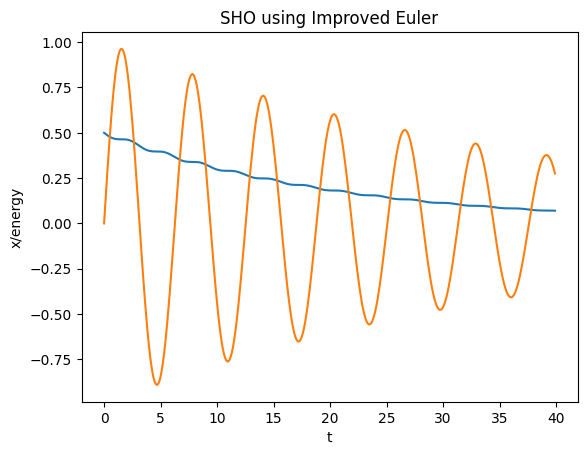

In [7]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np

def improved_euler(x0, v0, omega, h, T):
    N = int(T/h)

    ts = np.zeros(N)
    xs = np.zeros(N)
    vs = np.zeros(N)

    x = x0
    v = v0
    t = 0

    for i in range(N):
        ts[i] = t
        xs[i] = x
        vs[i] = v

        x_star = x + h*v
        v_star = v - h*(omega**2)*x

        x = x + h*(v + v_star)/2
        v = v - h*(omega**2)*(x + x_star)/2

        t += h

    return ts,xs,vs

t, x, v = improved_euler(
    x0=0.0,
    v0=1.0,
    omega=1.0,
    h=0.1,
    T=40
)
energy = 0.5*v**2 + 0.5*(1.0**2)*x**2
plt.plot(t, energy)
plt.title("Energy vs Time")

plt.plot(t, x)
plt.title("SHO using Improved Euler")
plt.xlabel("t")
plt.ylabel("x/energy")
plt.show()

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

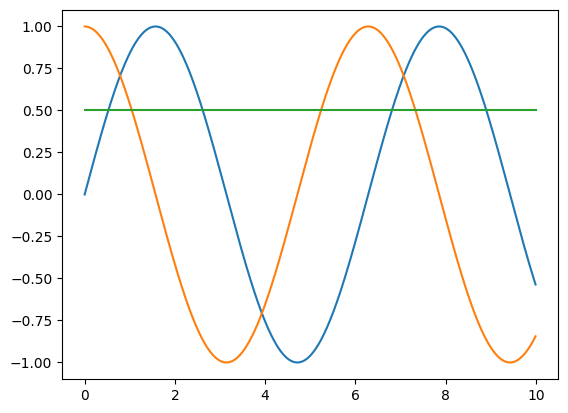

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def modified_euler(x0, v0, w, h, T):
    N = int(T/h)

    ts = np.zeros(N)
    xs = np.zeros(N)
    vs = np.zeros(N)

    x = x0
    v = v0
    t = 0

    for i in range(N):
        ts[i] = t
        xs[i] = x
        vs[i] = v

        # k1
        k1x = v
        k1v = -x*(w**2)

        # midpoint
        xmid = x + h*k1x/2
        vmid = v + h*k1v/2

        # k2
        k2x = vmid
        k2v = -xmid*(w**2)

        # update
        x = x + h*k2x
        v = v + h*k2v

        t = t + h

    return ts, xs, vs


t,x,v=modified_euler(0,1,1,0.01,10)
E=(x**2+v**2)/2
plt.plot(t,x)
plt.plot(t,v)
plt.plot(t,E)
plt

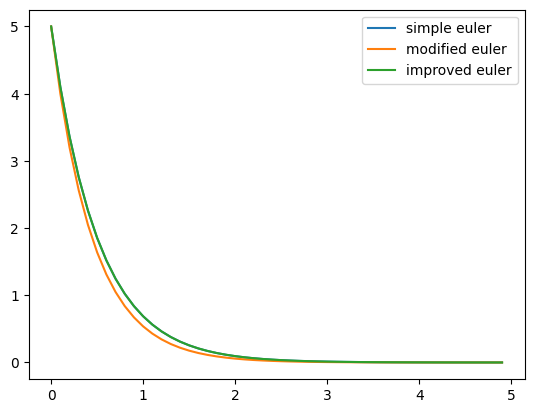

In [6]:
def f(t,y):
  dy=-2*y
  return dy

def simple_euler(y0,t0,h,T):
  N=int((T-t0)/h)
  ts=np.zeros(N)
  ys=np.zeros(N)

  t=t0
  y=y0
  for i in range(N):
    ts[i]=t
    ys[i]=y
    k1=f(t,y)
    y=y+h*k1
    t=t+h

  return ts,ys

def modified_euler(y0,t0,h,T):
  N=int((T-t0)/h)
  ts=np.zeros(N)
  ys=np.zeros(N)

  t=t0
  y=y0
  for i in range(N):
    ts[i]=t
    ys[i]=y
    k1=f(t,y)
    k2=f(t+h/2,y+h*k1/2)
    y=y+h*k2
    t=t+h

  return ts,ys

def improved_euler(y0,t0,h,T):
  N=int((T-t0)/h)
  ts=np.zeros(N)
  ys=np.zeros(N)

  t=t0
  y=y0
  for i in range(N):
    ts[i]=t
    ys[i]=y
    k1=f(t,y)
    k2=f(t+h,y+k1*h)
    y=y+0.5*h*(k1+k2)
    t=t+h
  return ts,ys

#parameter
y0=5
t0=0
T=5
h=0.1

ts1,ys1=simple_euler(y0,t0,h,T)
ts2,ys2=modified_euler(y0,t0,h,T)
ts3,ys3=improved_euler(y0,t0,h,T)

plt.plot(ts2,ys3,label="simple euler")
plt.plot(ts1,ys1,label="modified euler")
plt.plot(ts3,ys3,label="improved euler")
plt.legend()
plt.show()

enter half life value:0.5


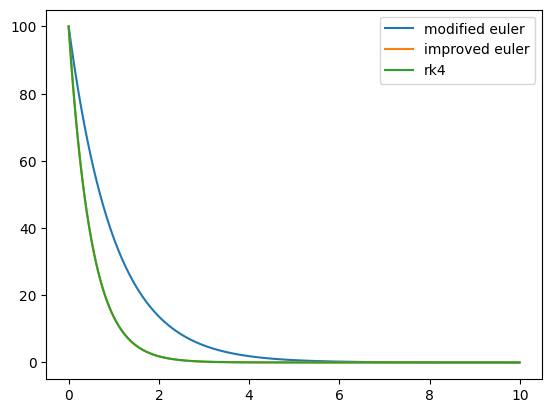

In [9]:
#radioactive decay
tau=float(input("enter half life value:"))
def f(t,n):
  dn=-n/tau
  return dn

def modified_euler(t0,n0,h,T):
  N=int((T-t0)/h)
  ns=np.zeros(N)
  ts=np.zeros(N)

  n=n0
  t=t0
  for i in range(N):
    ns[i]=n
    ts[i]=t
    k1=f(t,n)
    k2=f(t+h/2,n+k1*h/2)
    n=n+k2*h/2
    t=t+h
  return ns,ts

def improved_euler(t0,n0,h,T):
  N=int((T-t0)/h)
  ns=np.zeros(N)
  ts=np.zeros(N)

  n=n0
  t=t0
  for i in range(N):
    ns[i]=n
    ts[i]=t
    k1=f(t,n)
    k2=f(t+h,n+k1*h)
    n=n+0.5*h*(k1+k2)
    t=t+h
  return ns,ts

def rk4(t0,n0,h,T):
  N=int((T-t0)/h)
  ns=np.zeros(N)
  ts=np.zeros(N)

  n=n0
  t=t0
  for i in range(N):
    ts[i]=t
    ns[i]=n
    k1=f(t,n)
    k2=f(t+h/2,n+k1*h/2)
    k3=f(t+h/2,n+k2*h/2)
    k4=f(t+h,n+k3*h)
    n=n+h*(k1+2*k2+2*k3+k4)/6
    t=t+h
  return ns,ts

n0=100
T=10
h=0.01

ns1,ts1=modified_euler(0,n0,h,T)
ns2,ts2=improved_euler(0,n0,h,T)
ns3,ts3=rk4(0,n0,h,T)

plt.plot(ts1,ns1,label="modified euler")
plt.plot(ts2,ns2,label="improved euler")
plt.plot(ts3,ns3,label="rk4")
plt.legend()
plt.show()



enter value of spring constant:2


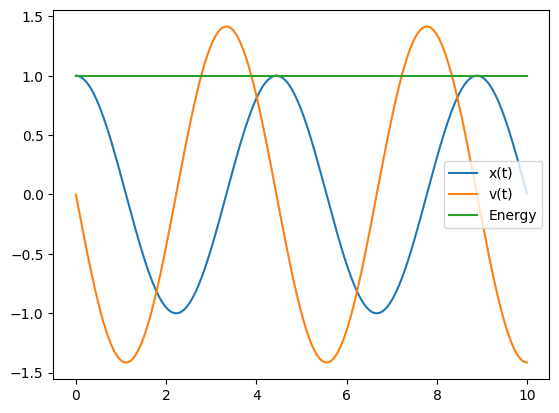

In [14]:
import numpy as np
import matplotlib.pyplot as plt

k = float(input("enter value of spring constant:"))

def f(t, z):
    x, v = z
    dx = v
    dv = -k*x
    return np.array([dx, dv])


def rk4(z0, t0, h, T):
    N = int((T - t0)/h)
    ts = np.zeros(N)
    zs = np.zeros((N, 2))

    z = z0.copy()
    t = t0

    for i in range(N):
        ts[i] = t
        zs[i] = z

        k1 = f(t, z)
        k2 = f(t + h/2, z + h*k1/2)
        k3 = f(t + h/2, z + h*k2/2)
        k4 = f(t + h, z + h*k3)

        z += h*(k1 + 2*k2 + 2*k3 + k4)/6
        t += h

    return ts, zs


# Initial conditions
z0 = np.array([1.0, 0.0])
t0 = 0
T = 10
h = 0.01

ts, zs = rk4(z0, t0, h, T)

x = zs[:,0]
v = zs[:,1]

# Correct energy
E = 0.5*v**2 + 0.5*k*x**2

plt.figure()
plt.plot(ts, x, label="x(t)")
plt.plot(ts, v, label="v(t)")
plt.plot(ts, E, label="Energy")
plt.legend()
plt.show()


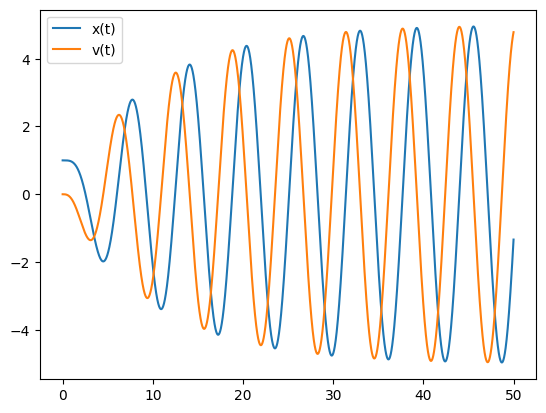

In [18]:
import numpy as np
import matplotlib.pyplot as plt

gamma = 0.1
omega0 = 1.0
F0 = 1.0
omega = omega0

def forced(t, Y):
    x, v = Y
    dxdt = v
    dvdt = -2*gamma*v - omega0**2*x + F0*np.cos(omega*t)
    return np.array([dxdt, dvdt])

def rk4(f, Y0, t0, h, T):
    N = int((T - t0)/h)
    ts = np.zeros(N)
    Ys = np.zeros((N, 2))

    Y = Y0.copy()
    t = t0

    for i in range(N):
        ts[i] = t
        Ys[i] = Y

        k1 = f(t, Y)
        k2 = f(t + h/2, Y + h*k1/2)
        k3 = f(t + h/2, Y + h*k2/2)
        k4 = f(t + h, Y + h*k3)

        Y += h*(k1 + 2*k2 + 2*k3 + k4)/6
        t += h

    return ts, Ys


ts, Ys = rk4(forced, np.array([1.0, 0.0]), 0, 0.01, 50)

plt.plot(ts, Ys[:,0], label="x(t)")
plt.plot(ts, Ys[:,1], label="v(t)")
plt.legend()
plt.show()



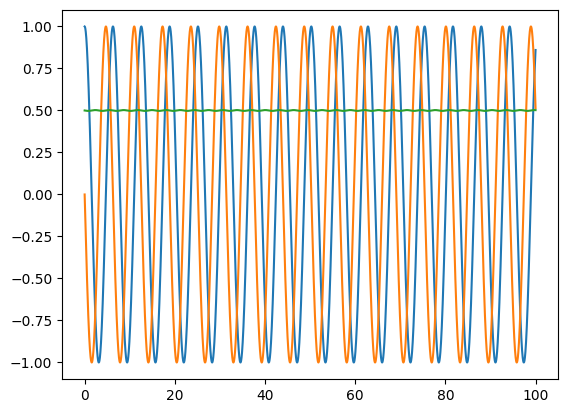

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def ec(x0,v0,t0,h,T):
  N=int((T-t0)/h)
  ts=np.zeros(N)
  xs=np.zeros(N)
  vs=np.zeros(N)
  t=t0
  x=x0
  v=v0

  for i in range(N):
    ts[i]=t
    xs[i]=x
    vs[i]=v

    v=v-h*x
    x=x+h*v
    t=t+h

  return ts,xs,vs

ts,xs,vs=ec(1.0,0.0,0,0.01,100)
E = 0.5*vs**2 + 0.5*xs**2
plt.plot(ts,xs)
plt.plot(ts,vs)
plt.plot(ts,E)
plt.show()


enter value of gamma:0.1
enter value of omega0:2


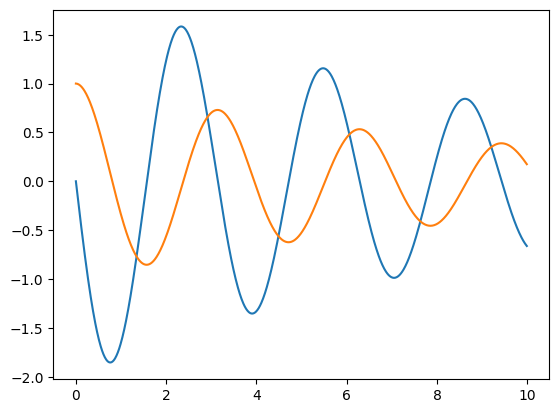

In [22]:
def ec(x0,v0,t0,gamma,omega0,h,T):
  N=int((T-t0)/h)
  xs=np.zeros(N)
  vs=np.zeros(N)
  ts=np.zeros(N)

  x=x0
  v=v0
  t=t0

  for i in range(N):
    xs[i]=x
    vs[i]=v
    ts[i]=t

    v=v+h*(-2*gamma*v-omega0**2 *x)
    x=x+h*v
    t=t+h

  return ts,xs,vs

gamma=float(input("enter value of gamma:"))
omega0=float(input("enter value of omega0:"))

ts,vs,xs=ec(1.0,0.0,0,gamma,omega0,0.01,10)

plt.plot(ts,xs,label="x(t)")
plt.plot(ts,vs,label="v(t)")
plt.show()